# 01 - Diabetes Risk Prediction: 1D CNN

Áp dụng **CNN 1D** cho dữ liệu bệnh nhân dạng bảng. Dataset được mô tả là 50.000 bản ghi tổng hợp với 41 cột, gồm nhân khẩu học, lâm sàng, xét nghiệm, lối sống và biến mục tiêu `Diabetes_Risk`. citeturn0search1

> Lưu ý: CNN 1D ở đây xem các feature sau preprocessing như một chuỗi 1 chiều. Đây là cách thực hành CNN, không có nghĩa thứ tự các cột có quan hệ thời gian.


## Kiến thức CNN được áp dụng

Notebook này minh họa trực tiếp các khái niệm:

- **Tensor / Channel / Feature map**
- **Convolution**: kernel/filter quét trên vùng cục bộ
- **Local connectivity**
- **Parameter sharing**
- **ReLU**: đưa phi tuyến vào mạng
- **Pooling / Downsampling**
- **Receptive field** tăng dần qua các block
- **Hierarchical feature extraction**
- **Function composition**:

\[
F = f_{classifier}\circ f_{block3}\circ f_{block2}\circ f_{block1}
\]

Mỗi block có dạng:

\[
f_{block}=f_{pool}\circ f_{ReLU}\circ f_{Conv}
\]

- **Loss → Backpropagation → Gradient → Optimizer** để học kernel/weights.


In [1]:

# ============================================================
# CNN FROM SCRATCH IN PYTORCH - COMMON SETUP
# ============================================================
import os, random, time, json, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:

# =========================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# =========================
# Nếu chạy Kaggle:
DATA_PATH = r"D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 05\diabetes\data\diabetes_risk_prediction_dataset.csv"

# Nếu chạy máy cá nhân, sửa thành đường dẫn CSV của bạn:
# DATA_PATH = r"D:\...\diabetes_risk_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (50000, 41)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High



Columns:
['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed', 'Diabetes_Risk']


In [3]:

# =========================
# 2. XÁC ĐỊNH TARGET + KHẢO SÁT
# =========================
TARGET = "Diabetes_Risk"

print(df[TARGET].value_counts(dropna=False))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

# Loại ID và các cột text/risk recommendation có khả năng không phù hợp
drop_cols = [c for c in ["Patient_ID"] if c in df.columns]

# Loại các cột sinh ra từ target/risk hoặc khuyến nghị nếu có.
# Bạn nên kiểm tra tên cột thực tế trước khi chạy.
leak_keywords = [
    "risk_score", "risk score", "recommendation", "doctor",
    "diagnosis", "status"
]
for c in df.columns:
    if c == TARGET:
        continue
    if any(k in c.lower() for k in leak_keywords):
        drop_cols.append(c)

drop_cols = sorted(set(drop_cols))
print("Drop:", drop_cols)


Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: int64

Missing values:


Weight_kg                  2962
Height_cm                  2945
Sleep_Hours                2017
Exercise_Hours_Per_Week    1992
HbA1c                      1974
Daily_Walking_Minutes      1964
HDL                        1000
LDL                        1000
Triglycerides              1000
Medication_Adherence       1000
Total_Cholesterol          1000
Blood_Glucose               959
Physical_Activity_Level     500
Age                         497
Patient_ID                    0
dtype: int64

Drop: ['AI_Health_Recommendation', 'Diabetes_Risk_Score', 'Doctor_Consultation_Needed', 'Patient_ID', 'Smoking_Status']


In [4]:

# =========================
# 3. PREPROCESS TABULAR DATA
# =========================
work = df.drop(columns=drop_cols, errors="ignore").copy()

# Target về 0/1.
# Nếu target đã là 0/1 thì giữ nguyên; nếu là Yes/No, True/False,... thì encode.
y_raw = work[TARGET]

if pd.api.types.is_numeric_dtype(y_raw):
    y = y_raw.astype(int).to_numpy()
else:
    classes = sorted(y_raw.dropna().astype(str).unique())
    print("Target classes:", classes)
    mapping = {v:i for i,v in enumerate(classes)}
    y = y_raw.astype(str).map(mapping).to_numpy()

X = work.drop(columns=[TARGET])

# Numeric -> median
num_cols = X.select_dtypes(include=np.number).columns
X_num = X[num_cols].copy()
X_num = X_num.replace([np.inf, -np.inf], np.nan)
X_num = X_num.fillna(X_num.median())

# Categorical -> one-hot
cat_cols = X.select_dtypes(exclude=np.number).columns
X_cat = pd.get_dummies(X[cat_cols].fillna("Unknown"), drop_first=False)

X_all = pd.concat([X_num, X_cat], axis=1).astype(np.float32)

# Chuẩn hóa từng feature
mean = X_all.mean()
std = X_all.std().replace(0, 1)
X_all = (X_all - mean) / std

X_np = X_all.to_numpy(dtype=np.float32)

print("Processed X:", X_np.shape)
print("y:", y.shape, "classes:", np.unique(y))


Target classes: ['High', 'Low', 'Moderate']
Processed X: (50000, 85)
y: (50000,) classes: [0 1 2]


In [5]:

# =========================
# 4. STRATIFIED SPLIT 70/15/15
# =========================
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Conv1d expects [N, C, L].
# Ta dùng C=1, L=số feature.
X_train = torch.tensor(X_train).unsqueeze(1)
X_val   = torch.tensor(X_val).unsqueeze(1)
X_test  = torch.tensor(X_test).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(torch.utils.data.TensorDataset(X_train,y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(torch.utils.data.TensorDataset(X_val,y_val), batch_size=256)
test_loader  = DataLoader(torch.utils.data.TensorDataset(X_test,y_test), batch_size=256)

print(X_train.shape)


torch.Size([35000, 1, 85])


In [6]:

# =========================
# 5. 1D CNN
# =========================
class CNN1D_Diabetes(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CNN1D_Diabetes(n_classes=len(np.unique(y))).to(DEVICE)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CNN1D_Diabetes(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)


In [7]:

# =========================
# 6. TRAIN: LOSS -> BACKPROP -> UPDATE
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()          # Backpropagation
            optimizer.step()         # Gradient update
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss/total, correct/total

EPOCHS = 20
history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
best_state, best_val = None, float("inf")

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_loss < best_val:
        best_val = va_loss
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"val loss={va_loss:.4f}, acc={va_acc:.4f}")

model.load_state_dict(best_state)


Epoch 01/20 | train loss=0.5066, acc=0.7782 | val loss=0.5453, acc=0.7693
Epoch 02/20 | train loss=0.3498, acc=0.8525 | val loss=0.3230, acc=0.8627
Epoch 03/20 | train loss=0.3024, acc=0.8715 | val loss=0.3345, acc=0.8475
Epoch 04/20 | train loss=0.2742, acc=0.8844 | val loss=0.3564, acc=0.8541
Epoch 05/20 | train loss=0.2612, acc=0.8902 | val loss=0.2726, acc=0.8792
Epoch 06/20 | train loss=0.2475, acc=0.8963 | val loss=0.5599, acc=0.8099
Epoch 07/20 | train loss=0.2425, acc=0.8988 | val loss=0.2685, acc=0.8891
Epoch 08/20 | train loss=0.2319, acc=0.9023 | val loss=0.2436, acc=0.8931
Epoch 09/20 | train loss=0.2257, acc=0.9056 | val loss=0.2361, acc=0.8940
Epoch 10/20 | train loss=0.2207, acc=0.9093 | val loss=0.3434, acc=0.8657
Epoch 11/20 | train loss=0.2179, acc=0.9121 | val loss=0.2374, acc=0.8968
Epoch 12/20 | train loss=0.2143, acc=0.9124 | val loss=0.2375, acc=0.8976
Epoch 13/20 | train loss=0.2093, acc=0.9138 | val loss=0.7031, acc=0.7009
Epoch 14/20 | train loss=0.2069, acc=0

<All keys matched successfully>

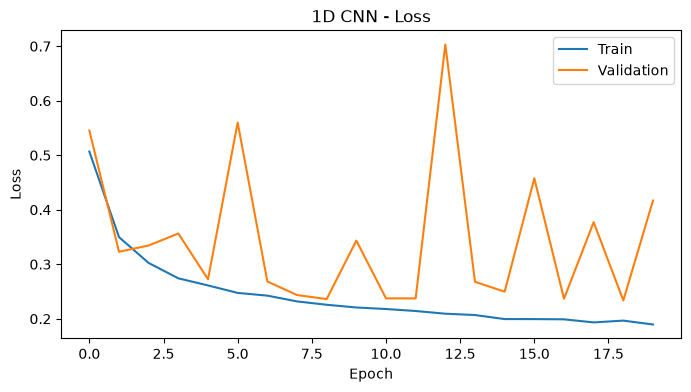

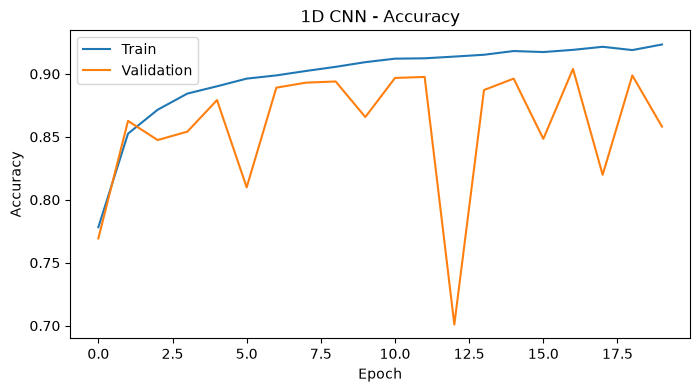

In [8]:

# =========================
# 7. TRAINING CURVES
# =========================
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("1D CNN - Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.title("1D CNN - Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()


              precision    recall  f1-score   support

           0     0.9405    0.9310    0.9357      5489
           1     0.7292    0.5000    0.5932        70
           2     0.7949    0.8269    0.8106      1941

    accuracy                         0.9000      7500
   macro avg     0.8216    0.7526    0.7799      7500
weighted avg     0.9009    0.9000    0.9001      7500



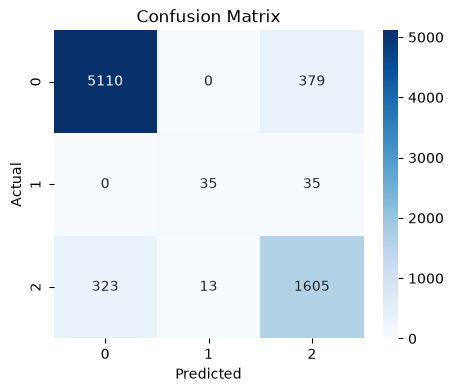

In [9]:

# =========================
# 8. TEST + CONFUSION MATRIX
# =========================
model.eval()
preds, truths = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())

print(classification_report(truths, preds, digits=4))
cm = confusion_matrix(truths, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### Liên hệ với lý thuyết

Ở notebook này, `Conv1d` tạo các feature map từ các vùng feature cục bộ; các filter được dùng lại trên toàn chiều feature nên thể hiện **parameter sharing**. Ba block liên tiếp tạo receptive field lớn hơn và biểu diễn đặc trưng theo tầng. Tuy nhiên, vì dữ liệu bảng không có cấu trúc không gian/tạm thời tự nhiên như ảnh hay tín hiệu, 1D CNN ở đây chủ yếu nhằm minh họa kiến thức CNN. Với bài báo cáo, nên nêu rõ hạn chế này.